
[![Image Name](https://cdn.kesci.com/upload/s2pw1in29.jpg)](https://www.heywhale.com/home/competition/652df88ecf318d693e2b20de/content/1)  


# 轻松上手心理学数据分析：第一关

## 🌟 目标解锁 🚀📊

1. 我们将一起探索心理学实验数据的基本结果
2. 学会用 pandas 和numpy进行数据清洗
3. 了解基本的可视化方法

### 🌐背景介绍

闯关题所涉及的数据集来源于2019年发表在nature communication上的一篇文章：  

Eisenberg, I. W., Bissett, P. G., Zeynep Enkavi, A., Li, J., MacKinnon, D. P., Marsch, L. A., & Poldrack, R. A. (2019). Uncovering the structure of self-regulation through data-driven ontology discovery. Nature Communications, 10(1), Article 1. https://doi.org/10.1038/s41467-019-10301-1  

#### 💐学习资源

Numpy中文文档：https://numpy123.com/article/basics/understanding_numpy/

Pandas：todo 放链接

注意：数据集存放在路径 '/home/mw/input/bayes3797/stroop.csv'，你可以使用该路径直接读取数据。



In [1]:
import pandas as pd

## STEP1：使用 pandas 读取数据

请使用 pandas 读取数据，并查看数据的基本信息。

1. 问题q1：查看数据集有哪些列，并存入变量a1  
2. 问题q2：查看反应时(“rt”)这一列中数值的类型，并存入变量a2  
3. 问题q3：统计未进行反应的试次（即'rt'列被赋值为-1），并存入变量a3  
4. 问题q4：统计反应时大于300且小于1000的行数，并存入变量a4

🐋：windows系统取消注释的快捷键是 ctrl+/, 苹果系统取消注释的快捷键是 command+/

In [19]:
# 从名为 "stroop.csv" 的 CSV 文件中读取数据并存储在 DataFrame 中
# pd.read_csv() 是 pandas 提供的函数，用于读取 CSV 文件并将其转换为 pandas 的 DataFrame 格式
df = pd.read_csv("/Users/ss/Documents/PyBayesian/Archive/2023/data/stroop.csv")

# 显示 DataFrame 的前几行数据
df.head()

,Unnamed: 0,battery_name,condition,correct,correct_response,exp_stage,experiment_exp_id,finishtime,focus_shifts,full_screen,key_press,possible_responses,rt,stim_color,stim_word,stimulus,time_elapsed,trial_id,trial_type,worker_id
0,stroop_s000_004,Self Regulation Battery,incongruent,0.0,66.0,practice,stroop,2016-07-22 04:44:22,0,True,71.0,"[66, 71, 82]",1141,blue,red,<div class = centerbox><div class = stroop-sti...,24318,stim,poldrack-categorize,s001
1,stroop_s000_006,Self Regulation Battery,congruent,1.0,82.0,practice,stroop,2016-07-22 04:44:22,0,True,82.0,"[66, 71, 82]",1048,red,red,<div class = centerbox><div class = stroop-sti...,27574,stim,poldrack-categorize,s001
2,stroop_s000_008,Self Regulation Battery,congruent,1.0,66.0,practice,stroop,2016-07-22 04:44:22,0,True,66.0,"[66, 71, 82]",855,blue,blue,<div class = centerbox><div class = stroop-sti...,30828,stim,poldrack-categorize,s001
3,stroop_s000_010,Self Regulation Battery,congruent,1.0,71.0,practice,stroop,2016-07-22 04:44:22,0,True,71.0,"[66, 71, 82]",421,green,green,<div class = centerbox><div class = stroop-sti...,34083,stim,poldrack-categorize,s001
4,stroop_s000_012,Self Regulation Battery,congruent,1.0,71.0,practice,stroop,2016-07-22 04:44:22,0,True,71.0,"[66, 71, 82]",694,green,green,<div class = centerbox><div class = stroop-sti...,37340,stim,poldrack-categorize,s001


In [16]:
# 从名为 "stroop.csv" 的 CSV 文件中读取数据并存储在 DataFrame 中
# df = pd.read_csv("/home/mw/input/bayes3797/stroop.csv")
df = pd.read_csv("/Users/ss/Documents/PyBayesian/Archive/2023/data/stroop.csv")
# 显示 DataFrame 的前几行数据
df.head()

# 问题q1：查看数据集有哪些列，并存入变量a1  
# 提示：你可以使用 `df.columns` 来获取数据集的所有列名。
a1 = df.columns

# 问题q2：查看反应时(“rt”)这一列中数值的类型，并存入变量a2  
# 提示：‘.dtype’函数可用于描述或获取数组中每个元素的类型
a2 = df['rt'].dtype

# 问题q3：统计未进行反应的试次（即'rt'列被赋值为-1），并存入变量a3  
# 提示：首先筛选出 'rt' 列中值为 -1 的行，使用条件筛选，并通过 .shape[0] 获取这些行的数量
a3 = df[df['rt'] == -1].shape[0]

# 问题q4：统计反应时大于300且小于1000的行数，并存入变量a4
# 提示：使用逻辑运算符，例如'&', 筛选出 'rt' 列中反应时大于 300 且小于 1000 的行，通过 .shape[0] 获取这些行的数量。
a4 = df[(df['rt'] > 300) & (df['rt'] < 1000)].shape[0]

## STEP2：数据预处理 

请对被试的数据进行以下预处理，将预处理后的数据存为新的数据框 `df2`。

1. 问题q1: 删除所有的练习试次  
2. 问题q2: 删除未进行反应的试次（被试未反应的试次中，rt被赋值为-1）  
3. 问题q3: 删除反应错误的试次（被试错误反应的试次中，correct被赋值为0）  
4. 问题q4: 按照被试、条件进行分组后，计算rt这一列的平均值  

将获得的结果存在一个新的数据框 `df_rt_mean` 中。

In [18]:
# ‘.copy’函数用于复制数据，避免对原数据进行修改
df2 = df.copy()

# 问题q1: 删除所有的练习试次  
# 提示：根据条件筛选数据：实验阶段不为 "practice" 的数据
df2 = df[df['trial_type'] != 'practice']

# 问题q2: 删除未进行反应的试次，即 rt被赋值为-1的试次
# 提示：使用条件筛选删除 rt 列中等于 -1 的行
df2 = df2[df2['rt'] != -1]

# 问题q3:删除反应错误的试次，即 correct被赋值为0的试次
# 提示：可以同样使用条件筛选，删除 correct 列中等于 0 的行（即反应错误的试次）。
df2 = df2[df2['correct'] != 0]

# 问题q4:按照被试("worker_id")和条件("condition")进行分组，并计算每组中 "rt" 列的平均值
# 提示：使用 groupby() 方法对 "worker_id" 和"condition"进行分组，然后对 rt 列计算均值，最后将结果存储在新的 DataFrame 中。
df_rt_mean = df2.groupby(['worker_id', 'condition'])['rt'].mean()

# 重置索引，将分组结果转换为 DataFrame
df_rt_mean = df_rt_mean.reset_index()

## STEP2：数据框操作，合并数据框，长数据转化为宽数据

1. 问题q1: 使用 pandas 库中的 `merge()` 函数，将两个数据框(`df_rt_mean` 和 `df_acc_mean`)进行合并。
   - 注意：`df_rt_mean` 为上一步计算的结果，`df_acc_mean` 的结果已提供（通过运行下列代码框获得）。
   - 请将合并后的数据框命名为 `df_merged`。
   - 提示: 可以使用 `how="inner"` 参数按照两个数据框共有的列进行拼接

In [21]:
# 将 df_rt_mean 和 df_acc 进行拼接，inner表示按照两个数据框共有的列进行拼接
df_acc_mean = df2.groupby(["worker_id", "condition"])["correct"].mean()
df_acc_mean = df_acc_mean.reset_index()

# 问题q1: 使用 pandas 库中的 merge() 函数，将两个数据框(`df_rt_mean` 和 `df_acc_mean`)进行合并
df_merged = pd.merge(df_rt_mean, df_acc_mean, how='inner')
df_merged


,worker_id,condition,rt,correct
0,s001,congruent,725.574074,1.0
1,s001,incongruent,861.000000,1.0
2,s002,congruent,698.561404,1.0
3,s002,incongruent,809.527273,1.0
4,s003,congruent,568.633333,1.0
...,...,...,...,...
1039,s557,incongruent,786.086957,1.0
1040,s559,congruent,682.237288,1.0
1041,s559,incongruent,886.294118,1.0
1042,s560,congruent,747.220339,1.0


2. 问题q2: 将数据 `df_merged` 从长数据转化为宽数据。
   - 提示，可使用 pandas 库中的 `pivot_table()` 或 `unstack` 函数来实现长数据转化为宽数据。
   - 请重命名列名为 `rt_congruent`, `rt_incongruent`, `acc_congruent`, `acc_incongruent`。
   - 请将转化后的数据框命名为 `df_wide`。

In [23]:
# 问题q2: 将数据 `df_merged` 从长数据转化为宽数据。
# 提示：使用 pivot_table() 方法，将 'worker_id' 列作为索引，'condition' 列作为列名，'rt' 和 'correct' 列作为值。
df_wide = df_merged.pivot_table(index='worker_id', columns='condition', values=['rt', 'correct'])

# 重命名列
# 提示：使用 df.columns 属性来获取列名，然后修改列名
df_wide.columns = ['rt_congruent', 'rt_incongruent', 'acc_congruent', 'acc_incongruent']

# 重置索引，保证输出是一个普通的DataFrame
# 提示：使用 reset_index() 方法
df_wide = df_wide.reset_index()

## STEP3：基本绘图  

1. 问题q1: 绘制出一致条件与不一致条件下的反应时分布密度图(density plot)  
     - 提示：可以使用 `df.groupby(...)[...].plot(kind="density", legend=True)`绘制不同条件下的分布密度图
2. 问题q2: 分别绘制出一致条件与不一致条件下的反应时箱线图(boxplot)  
     - 提示，可以使用 `df.groupby(...).boxplot(column=...)`绘制不同条件下的箱线图。

🤔 思考：如果需要将绘图样式修改为APA7格式，可以怎么修改代码呢？

condition
congruent      Axes(0.125,0.11;0.775x0.77)
incongruent    Axes(0.125,0.11;0.775x0.77)
Name: rt, dtype: object

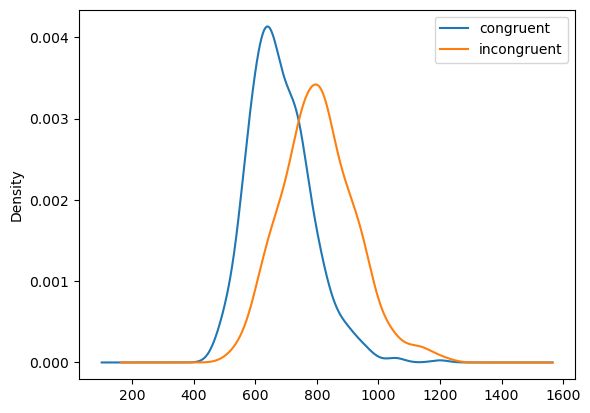

In [24]:
# 问题q1: 绘制出一致条件与不一致条件下的反应时分布密度图(density plot)
# 注：如果你不知道如何绘制密度图，可以查阅 pandas 或 seaborn 的文档

df_merged.groupby('condition')['rt'].plot(kind="density", legend=True)


congruent           Axes(0.1,0.15;0.363636x0.75)
incongruent    Axes(0.536364,0.15;0.363636x0.75)
dtype: object

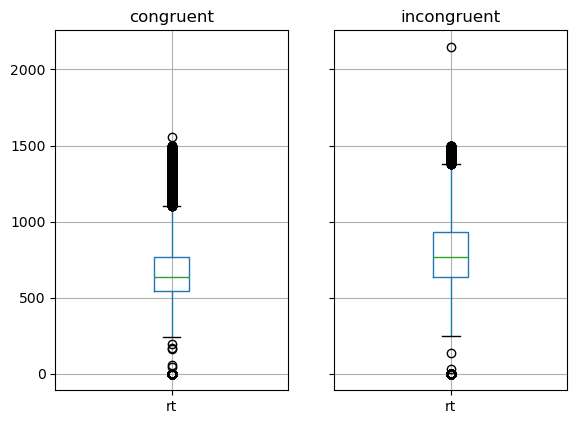

In [28]:
# 问题q2: 分别绘制出一致条件与不一致条件下的反应时箱线图(boxplot)  
df.groupby('condition').boxplot(column='rt')

## STEP4：将结果保存为 csv 文件  
💡 这一步的代码你无需修改，直接运行即可。

In [29]:
result = pd.DataFrame({'id': [f"q{i}" for i in range(1, 5)],  
                        'result': [a1.to_list(), a2, a3, a4]})  

result.to_csv("result11.csv", index=None)

df2.to_csv("result12.csv", index=None)

df_rt_mean.to_csv("result13.csv", index=None)

df_merged.to_csv("result14.csv", index=None)
df_wide.to_csv("result15.csv", index=None)

## STEP5: 提交 csv 文件，获取分数结果  
经过上述几个步骤，你的 csv 答案文件已经准备完毕了，最后让我们提交答案文件，看看是否正确。  

**提交方法：**  

1、拷贝提交 token  

去对应关卡的 [提交页面](https://www.heywhale.com/home/competition/652df88ecf318d693e2b20de/submit)，找到闯关题 1 任务，看到了你的 token 嘛？  
拷贝它。  

> 记得：每个任务的 token 不一样。  

2、粘贴到下方 cell 里，替换 XXXXXXX， Shift+Enter，运行 。

In [30]:
# 运行这个Cell 下载提交工具

!wget -nv -O heywhale_submit https://cdn.kesci.com/submit_tool/v4/heywhale_submit&&chmod +x heywhale_submit

# 运行提交工具
# 把下方XXXXXXX替换为你的 Token
# 改完看起来像是：!./heywhale_submit -token 586eeef71cb92941 -file answer_psy_1_1.csv

!./heywhale_submit -token XXXXXXX -file answer_psy_1_1.csv  # 替换XXXXXXX；注意不可增减任何空格或其他字符

zsh:1: command not found: wget
zsh:1: no such file or directory: ./heywhale_submit


运行成功、显示提交完成后，即可去 [提交页面](https://www.heywhale.com/home/competition/652df88ecf318d693e2b20de/submit) 看成绩。满分即可继续完成下个闯关题。  

没有成功也不怕，看下报错信息，对照教案与[小黄鸭 debug 法](https://baike.baidu.com/item/%E5%B0%8F%E9%BB%84%E9%B8%AD%E8%B0%83%E8%AF%95%E6%B3%95/16569594)排查下，改完重新走 STEP 5、6 提交咯。